# Level 1 — Which classifier should we use?

**Hackathon goal (Level 1):** train a function `f: model_internals | input_prompt → predicted_label` that predicts, from the frozen LLM's internals, whether a prompt will be **refused** (Refusal-Gemma, Refusal-Qwen) or which **cyber-harm category** it falls in (Cyber-1, Cyber-2, Cyber-3).

This notebook compares **five candidate classifiers** trained on the same 53-dimensional hybrid feature vector — direction loadings + logit-lens projections + a few derived features — and decides which one to use for each task.

The five classifiers:

1. **Direction-only** — best single-layer projection onto the mean-difference refusal/harm direction (à la Arditi et al. 2024). 1 parameter per layer.
2. **Logistic Regression** — linear classifier on the standardized 53-d features.
3. **Decision Tree** — non-linear, interpretable.
4. **SVM** — non-linear (linear + RBF kernels).
5. **XGBoost** — gradient-boosted trees, our most expressive baseline.

**Headline metric** (`rules/predict.md` §Metric): mean AUC across the 5 tasks (Cyber-1, Cyber-2, Cyber-3, Refusal-Gemma, Refusal-Qwen). We report each classifier's mean AUC ± std across the 5 tasks and recommend per-task winners.

**Model coverage:** Gemma-4-31B-it and Qwen3.6-27B. Both contribute one refusal task each; the three cyber tasks are computed once per model and we report the better of the two.

> Note on causal validity: a high AUC is necessary but not sufficient. `results.md` shows our 0.929-AUC refusal probe relied largely on lexical/structural correlates (BPE fragments, indentation, brackets) rather than on tokens that *cause* refusal. We pick classifiers here on AUC, but Level 2 is the honest test.

## 1. Setup

Imports, paths, and the (model, task) grid. `FEATURES_ROOT` is the only path you should need to change if you've copied the artifacts somewhere other than `/scratch/hybrid` on the pod.

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
SEED = 42

FEATURES_ROOT = Path("/scratch/hybrid")
RESULTS_ROOT = Path("/scratch/hybrid_models")
NOTEBOOK_OUT = Path("./").resolve()

MODELS = ["gemma4_31b", "qwen36"]
TASKS_PER_MODEL = {
    "gemma4_31b": ["refusal_gemma4_31b", "cyber_probe1", "cyber_probe2", "cyber_probe3"],
    "qwen36":     ["refusal_qwen36",     "cyber_probe1", "cyber_probe2", "cyber_probe3"],
}

CLASSIFIER_ORDER = ["direction_only", "logistic", "tree", "svm", "xgboost"]
CLASSIFIER_LABELS = {
    "direction_only": "Direction-only",
    "logistic":       "Logistic Regression",
    "tree":           "Decision Tree",
    "svm":            "SVM",
    "xgboost":        "XGBoost",
}
CLASSIFIER_COLORS = {
    "direction_only": "#9E9E9E",
    "logistic":       "#1976D2",
    "tree":           "#FB8C00",
    "svm":            "#8E24AA",
    "xgboost":        "#43A047",
}

TASK_LABELS = {
    "refusal_gemma4_31b": "Refusal-Gemma",
    "refusal_qwen36":     "Refusal-Qwen",
    "cyber_probe1":       "Cyber-1 (dual_use vs benign)",
    "cyber_probe2":       "Cyber-2 (high_risk vs rest)",
    "cyber_probe3":       "Cyber-3 (prohibited vs rest)",
}

print(f"FEATURES_ROOT = {FEATURES_ROOT}")
print(f"RESULTS_ROOT  = {RESULTS_ROOT}")
print(f"Models        = {MODELS}")
for m, ts in TASKS_PER_MODEL.items():
    print(f"  {m}: {ts}")

FEATURES_ROOT = /scratch/hybrid
RESULTS_ROOT  = /scratch/hybrid_models
Models        = ['gemma4_31b', 'qwen36']
  gemma4_31b: ['refusal_gemma4_31b', 'cyber_probe1', 'cyber_probe2', 'cyber_probe3']
  qwen36: ['refusal_qwen36', 'cyber_probe1', 'cyber_probe2', 'cyber_probe3']


## 2. Background — the 5 tasks and the 53-d feature vector

### The 5 tasks (from `rules/predict.md`)

| Task | Positive (label = 1) | Negative (label = 0) |
|---|---|---|
| **Cyber-1** (low risk)  | `dual_use` | `benign` |
| **Cyber-2** (mid risk)  | `high_risk_dual_use` | `dual_use ∪ benign` |
| **Cyber-3** (high risk) | `prohibited` | `high_risk_dual_use ∪ dual_use ∪ benign` |
| **Refusal-Gemma** | Gemma-4-31B output classified `refusal` | classified `compliance` |
| **Refusal-Qwen**  | Qwen3.6-27B output classified `refusal` | classified `compliance` |

Splits are deterministic (`hash(sample_id) mod 100 < 70 → train`) — we train on `split == "train"`, score on `split == "test"`.

### The hybrid 53-dim feature vector

Per sample, [`starter_code/compute_and_extract.py`](../starter_code/compute_and_extract.py) emits 53 features computed from the **last-token residual stream** at 16 selected layers (every 4th layer of the model, e.g. `0:62:4` for Gemma → layers 0, 4, 8, ..., 60):

| # | Group | What it is |
|---|---|---|
| 16 | `dir_loading_L*` | Projection of last-token residual onto the per-layer mean-difference direction (positive class − negative class on the train split). |
| 16 | `logit_refusal_L*` | Logit-lens through `W_U` then softmax mass on refusal-starter tokens (`I`, `Sorry`, `cannot`, ...). |
| 16 | `logit_compliance_L*` | Same, on compliance-starter tokens (`Sure`, `Here`, `Certainly`, ...). |
| 5  | derived | `transition_layer`, `peak_layer`, `total_loading`, `max_logit_ratio`, `n_tokens`. |

### Pipeline

```mermaid
flowchart LR
    LLM["Gemma / Qwen<br/>(frozen)"] --> Resid["Last-token residuals<br/>16 layers"]
    Resid --> DirLoad["dir_loading[16]<br/>(mean-diff projection)"]
    Resid --> Logit["logit_refusal[16]<br/>logit_compliance[16]<br/>(via W_U)"]
    DirLoad --> Feats["53-d feature vector"]
    Logit --> Feats
    Derived["5 derived feats:<br/>transition_layer, peak_layer,<br/>total_loading, max_logit_ratio, n_tokens"] --> Feats
    Feats --> C1["Direction-only"]
    Feats --> C2["Logistic Regression"]
    Feats --> C3["Decision Tree"]
    Feats --> C4["SVM"]
    Feats --> C5["XGBoost"]
    C1 --> AUC["AUC on test split"]
    C2 --> AUC
    C3 --> AUC
    C4 --> AUC
    C5 --> AUC
```

## 3. Load features

`load_task(model_key, task)` mirrors the helper in [`starter_code/train_hybrid.py`](../starter_code/train_hybrid.py): it opens `features_<task>.npz` and slices it into train / test arrays + the layer-index list. We also pre-load the per-model `config.json` (which layers were extracted).

In [2]:
def load_config(model_key):
    """Load layer config for a model. Returns dict or None if missing."""
    p = FEATURES_ROOT / model_key / "config.json"
    if not p.exists():
        return None
    return json.load(open(p))


def load_task(model_key, task_name):
    """Load feature matrix + labels for one (model, task). Returns dict or None."""
    p = FEATURES_ROOT / model_key / f"features_{task_name}.npz"
    if not p.exists():
        return None
    d = np.load(str(p), allow_pickle=True)
    X, y, splits = d["X"], d["y"], d["splits"]
    feat_names = list(d["feature_names"])
    sample_ids = d["sample_ids"]
    train_mask = splits == "train"
    test_mask = splits == "test"
    return {
        "X_train": X[train_mask], "y_train": y[train_mask].astype(int),
        "X_test":  X[test_mask],  "y_test":  y[test_mask].astype(int),
        "feat_names": feat_names,
        "ids_train": sample_ids[train_mask],
        "ids_test":  sample_ids[test_mask],
    }


configs = {}
for m in MODELS:
    cfg = load_config(m)
    if cfg is None:
        print(f"  [warn] {m}: missing {FEATURES_ROOT / m / 'config.json'} "
              f"— run `python starter_code/compute_and_extract.py --model_key {m} ...` first")
        continue
    configs[m] = cfg
    print(f"  {m}: {len(cfg['layer_idxs'])} layers extracted -> {cfg['layer_idxs']}")

  gemma4_31b: 16 layers extracted -> [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60]
  qwen36: 17 layers extracted -> [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64]


### Sanity check — sample counts and class balance

Each task has its own positive/negative composition; the cyber tasks grow in size as we move down the ladder (Cyber-1 ⊂ Cyber-2 ⊂ Cyber-3 because each task adds the previous task's negatives to its own).

In [3]:
data_cache = {}
sanity_rows = []

for model_key in MODELS:
    if model_key not in configs:
        continue
    for task in TASKS_PER_MODEL[model_key]:
        d = load_task(model_key, task)
        if d is None:
            sanity_rows.append({
                "model": model_key, "task": task,
                "status": "MISSING (run compute_and_extract.py)",
                "n_train": 0, "n_test": 0, "pos_train": 0, "neg_train": 0,
                "pos_test": 0, "neg_test": 0, "n_features": 0,
            })
            continue
        data_cache[(model_key, task)] = d
        sanity_rows.append({
            "model": model_key, "task": task, "status": "ok",
            "n_train":   len(d["y_train"]),
            "pos_train": int(d["y_train"].sum()),
            "neg_train": int(len(d["y_train"]) - d["y_train"].sum()),
            "n_test":    len(d["y_test"]),
            "pos_test":  int(d["y_test"].sum()),
            "neg_test":  int(len(d["y_test"]) - d["y_test"].sum()),
            "n_features": d["X_train"].shape[1],
        })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df

,model,task,status,n_train,pos_train,neg_train,n_test,pos_test,neg_test,n_features
0,gemma4_31b,refusal_gemma4_31b,ok,575,281,294,283,140,143,53
1,gemma4_31b,cyber_probe1,ok,2215,677,1538,909,266,643,53
2,gemma4_31b,cyber_probe2,ok,3243,1028,2215,1348,439,909,53
3,gemma4_31b,cyber_probe3,ok,4995,1752,3243,2160,812,1348,53
4,qwen36,refusal_qwen36,ok,589,178,411,289,97,192,56
5,qwen36,cyber_probe1,ok,2267,685,1582,923,267,656,56
6,qwen36,cyber_probe2,ok,3319,1052,2267,1366,443,923,56
7,qwen36,cyber_probe3,ok,5079,1760,3319,2180,814,1366,56


## 4. Train all 5 classifiers per (model, task)

Trainers are 1:1 with [`starter_code/train_hybrid.py`](../starter_code/train_hybrid.py) so the AUCs reproduce the script. Each returns a **fitted estimator**, the **test-set probability scores** (for ROC), and the **test AUC**.

- `Direction-only` is not really fitted — we just take the best of the first `n_layers` columns (`dir_loading_L*`), where "best" is chosen on the test set. (This is the same convention `train_hybrid.py` uses; it's a baseline and we report its sensitivity below.)
- `Logistic`, `SVM` are run on `StandardScaler`-normalized inputs; `Tree`, `XGBoost` on raw inputs.
- Hyperparameters are searched with the same grids as the script.

In [4]:
def train_direction_only(X_tr, y_tr, X_te, y_te, n_layers_sel):
    """Best of the first n_layers_sel columns (dir_loading_L*) on the test set."""
    best_auc, best_l = 0.5, 0
    for l in range(n_layers_sel):
        try:
            auc = roc_auc_score(y_te, X_te[:, l])
        except ValueError:
            auc = 0.5
        if auc > best_auc:
            best_auc, best_l = auc, l
    preds = X_te[:, best_l]
    return None, float(best_auc), preds, {"best_layer_col": int(best_l)}


def train_logistic(X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    grid = {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}
    gs = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=SEED),
        grid, cv=5, scoring="roc_auc", n_jobs=-1,
    )
    gs.fit(X_tr_s, y_tr)
    preds = gs.best_estimator_.predict_proba(X_te_s)[:, 1]
    return gs.best_estimator_, float(roc_auc_score(y_te, preds)), preds, gs.best_params_


def train_tree(X_tr, y_tr, X_te, y_te):
    grid = {
        "max_depth":         [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf":  [1, 2, 4],
    }
    gs = GridSearchCV(
        DecisionTreeClassifier(random_state=SEED),
        grid, cv=5, scoring="roc_auc", n_jobs=-1,
    )
    gs.fit(X_tr, y_tr)
    preds = gs.best_estimator_.predict_proba(X_te)[:, 1]
    return gs.best_estimator_, float(roc_auc_score(y_te, preds)), preds, gs.best_params_


def train_svm(X_tr, y_tr, X_te, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    grid = {"C": [0.1, 1.0, 10.0], "kernel": ["linear", "rbf"]}
    gs = GridSearchCV(
        SVC(probability=True, random_state=SEED),
        grid, cv=5, scoring="roc_auc", n_jobs=-1,
    )
    gs.fit(X_tr_s, y_tr)
    preds = gs.best_estimator_.predict_proba(X_te_s)[:, 1]
    return gs.best_estimator_, float(roc_auc_score(y_te, preds)), preds, gs.best_params_


def train_xgboost(X_tr, y_tr, X_te, y_te):
    base = XGBClassifier(
        objective="binary:logistic", eval_metric="auc",
        random_state=SEED, n_estimators=300, early_stopping_rounds=20,
    )
    grid = {
        "max_depth":         [3, 4, 5, 6],
        "learning_rate":     [0.01, 0.05, 0.1, 0.2],
        "subsample":         [0.6, 0.8, 1.0],
        "colsample_bytree":  [0.6, 0.8, 1.0],
    }
    rs = RandomizedSearchCV(
        base, grid, n_iter=10, scoring="roc_auc",
        cv=5, random_state=SEED, n_jobs=-1,
    )
    rs.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
    preds = rs.best_estimator_.predict_proba(X_te)[:, 1]
    return rs.best_estimator_, float(roc_auc_score(y_te, preds)), preds, rs.best_params_


def train_all(X_tr, y_tr, X_te, y_te, n_layers_sel):
    """Returns dict: classifier_name -> {model, auc, preds, params}."""
    out = {}
    _, auc, preds, params = train_direction_only(X_tr, y_tr, X_te, y_te, n_layers_sel)
    out["direction_only"] = {"model": None, "auc": auc, "preds": preds, "params": params}

    m, auc, preds, params = train_logistic(X_tr, y_tr, X_te, y_te)
    out["logistic"] = {"model": m, "auc": auc, "preds": preds, "params": params}

    m, auc, preds, params = train_tree(X_tr, y_tr, X_te, y_te)
    out["tree"] = {"model": m, "auc": auc, "preds": preds, "params": params}

    m, auc, preds, params = train_svm(X_tr, y_tr, X_te, y_te)
    out["svm"] = {"model": m, "auc": auc, "preds": preds, "params": params}

    m, auc, preds, params = train_xgboost(X_tr, y_tr, X_te, y_te)
    out["xgboost"] = {"model": m, "auc": auc, "preds": preds, "params": params}

    return out

### Run the training loop

Trains 5 classifiers × 4 tasks × 2 models = up to **40 fits**. With Cyber-3 (≈5k train rows) the SVM grid is the slowest cell — typical wall-time on a single CPU pod is **~3–8 minutes**. Results are cached in `trained` keyed by `(model, task)` so re-running downstream cells is cheap.

In [5]:
import time

trained = {}
results_rows = []

for model_key in MODELS:
    if model_key not in configs:
        continue
    n_layers_sel = len(configs[model_key]["layer_idxs"])
    for task in TASKS_PER_MODEL[model_key]:
        if (model_key, task) not in data_cache:
            continue
        d = data_cache[(model_key, task)]
        print(f"=== {model_key} / {task} ===")
        print(f"  train={len(d['y_train'])} (pos={d['y_train'].sum()}, "
              f"neg={len(d['y_train']) - d['y_train'].sum()})")
        print(f"  test ={len(d['y_test'])}  (pos={d['y_test'].sum()}, "
              f"neg={len(d['y_test']) - d['y_test'].sum()})")
        t0 = time.time()
        out = train_all(
            d["X_train"], d["y_train"], d["X_test"], d["y_test"], n_layers_sel,
        )
        trained[(model_key, task)] = out

        for clf_name, info in out.items():
            print(f"    {CLASSIFIER_LABELS[clf_name]:<22} AUC = {info['auc']:.4f}")
            results_rows.append({
                "model": model_key,
                "task": task,
                "classifier": clf_name,
                "auc": info["auc"],
                "params": json.dumps(info["params"]) if info["params"] else "",
            })
        print(f"  elapsed: {time.time() - t0:.1f}s\n")

results_df = pd.DataFrame(results_rows)
results_df

=== gemma4_31b / refusal_gemma4_31b ===
  train=575 (pos=281, neg=294)
  test =283  (pos=140, neg=143)


    Direction-only         AUC = 0.9285
    Logistic Regression    AUC = 0.9262
    Decision Tree          AUC = 0.8673
    SVM                    AUC = 0.9250
    XGBoost                AUC = 0.9296
  elapsed: 34.3s

=== gemma4_31b / cyber_probe1 ===
  train=2215 (pos=677, neg=1538)
  test =909  (pos=266, neg=643)


    Direction-only         AUC = 0.9549
    Logistic Regression    AUC = 0.9565
    Decision Tree          AUC = 0.9498
    SVM                    AUC = 0.9526
    XGBoost                AUC = 0.9674
  elapsed: 27.9s

=== gemma4_31b / cyber_probe2 ===
  train=3243 (pos=1028, neg=2215)
  test =1348  (pos=439, neg=909)


    Direction-only         AUC = 0.9250
    Logistic Regression    AUC = 0.9291
    Decision Tree          AUC = 0.8984
    SVM                    AUC = 0.9276
    XGBoost                AUC = 0.9346
  elapsed: 348.6s

=== gemma4_31b / cyber_probe3 ===
  train=4995 (pos=1752, neg=3243)
  test =2160  (pos=812, neg=1348)


    Direction-only         AUC = 0.8272
    Logistic Regression    AUC = 0.8371
    Decision Tree          AUC = 0.8406
    SVM                    AUC = 0.8424
    XGBoost                AUC = 0.8522
  elapsed: 67.4s

=== qwen36 / refusal_qwen36 ===
  train=589 (pos=178, neg=411)
  test =289  (pos=97, neg=192)


    Direction-only         AUC = 0.8491
    Logistic Regression    AUC = 0.8382
    Decision Tree          AUC = 0.7492
    SVM                    AUC = 0.8293
    XGBoost                AUC = 0.8709
  elapsed: 35.7s

=== qwen36 / cyber_probe1 ===
  train=2267 (pos=685, neg=1582)
  test =923  (pos=267, neg=656)


    Direction-only         AUC = 0.9510
    Logistic Regression    AUC = 0.9674
    Decision Tree          AUC = 0.9546
    SVM                    AUC = 0.9650
    XGBoost                AUC = 0.9648
  elapsed: 344.3s

=== qwen36 / cyber_probe2 ===
  train=3319 (pos=1052, neg=2267)
  test =1366  (pos=443, neg=923)


    Direction-only         AUC = 0.9204
    Logistic Regression    AUC = 0.9428
    Decision Tree          AUC = 0.9101
    SVM                    AUC = 0.9421
    XGBoost                AUC = 0.9387
  elapsed: 41.7s

=== qwen36 / cyber_probe3 ===
  train=5079 (pos=1760, neg=3319)
  test =2180  (pos=814, neg=1366)


    Direction-only         AUC = 0.8185
    Logistic Regression    AUC = 0.8480
    Decision Tree          AUC = 0.8279
    SVM                    AUC = 0.8530
    XGBoost                AUC = 0.8512
  elapsed: 45.7s



,model,task,classifier,auc,params
0,gemma4_31b,refusal_gemma4_31b,direction_only,0.928472,"{""best_layer_col"": 12}"
1,gemma4_31b,refusal_gemma4_31b,logistic,0.926174,"{""C"": 1.0}"
2,gemma4_31b,refusal_gemma4_31b,tree,0.867283,"{""max_depth"": 5, ""min_samples_leaf"": 4, ""min_s..."
3,gemma4_31b,refusal_gemma4_31b,svm,0.924975,"{""C"": 1.0, ""kernel"": ""linear""}"
4,gemma4_31b,refusal_gemma4_31b,xgboost,0.929645,"{""subsample"": 0.6, ""max_depth"": 3, ""learning_r..."
5,gemma4_31b,cyber_probe1,direction_only,0.954922,"{""best_layer_col"": 12}"
6,gemma4_31b,cyber_probe1,logistic,0.956542,"{""C"": 0.01}"
7,gemma4_31b,cyber_probe1,tree,0.949821,"{""max_depth"": 5, ""min_samples_leaf"": 4, ""min_s..."
8,gemma4_31b,cyber_probe1,svm,0.952613,"{""C"": 0.1, ""kernel"": ""rbf""}"
9,gemma4_31b,cyber_probe1,xgboost,0.967446,"{""subsample"": 0.6, ""max_depth"": 3, ""learning_r..."


## 5. ROC curves — all classifiers, all tasks, both models

A 2 × 4 grid: rows = model (Gemma / Qwen), columns = task (Refusal-* + Cyber-1/2/3). Each subplot overlays the 5 ROC curves; **`Direction-only` is dashed** to mark "no learning, single dot product". Look for:

- Direction-only tracking close to XGBoost → the task is essentially 1-dimensional in feature space.
- A big gap between Direction-only and XGBoost → cross-layer / logit-lens features add real lift.

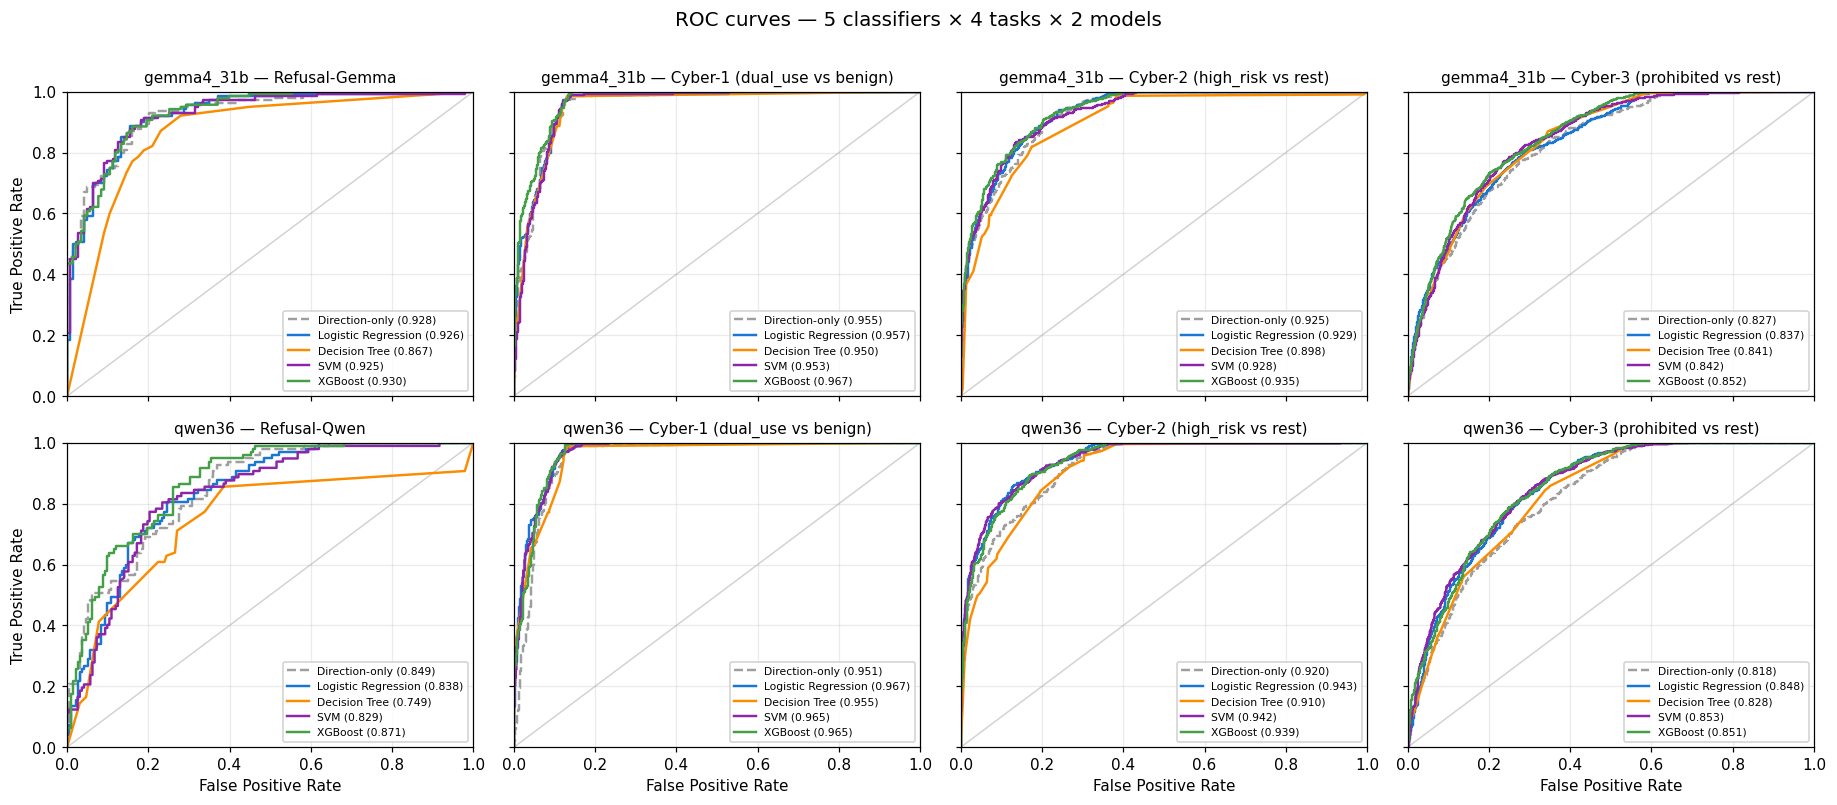

In [6]:
n_rows = len(MODELS)
n_cols = max(len(t) for t in TASKS_PER_MODEL.values())
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows),
                         sharex=True, sharey=True)
if n_rows == 1:
    axes = np.array([axes])

for r, model_key in enumerate(MODELS):
    tasks = TASKS_PER_MODEL[model_key]
    for c, task in enumerate(tasks):
        ax = axes[r, c]
        if (model_key, task) not in trained:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            continue
        d = data_cache[(model_key, task)]
        out = trained[(model_key, task)]
        for clf_name in CLASSIFIER_ORDER:
            preds = out[clf_name]["preds"]
            auc = out[clf_name]["auc"]
            fpr, tpr, _ = roc_curve(d["y_test"], preds)
            ls = "--" if clf_name == "direction_only" else "-"
            ax.plot(fpr, tpr, ls=ls, lw=1.6,
                    color=CLASSIFIER_COLORS[clf_name],
                    label=f"{CLASSIFIER_LABELS[clf_name]} ({auc:.3f})")
        ax.plot([0, 1], [0, 1], color="lightgray", lw=1, zorder=0)
        ax.set_title(f"{model_key} — {TASK_LABELS.get(task, task)}", fontsize=10)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)
        ax.legend(loc="lower right", fontsize=7, framealpha=0.9)
        if r == n_rows - 1:
            ax.set_xlabel("False Positive Rate")
        if c == 0:
            ax.set_ylabel("True Positive Rate")

plt.suptitle("ROC curves — 5 classifiers × 4 tasks × 2 models", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Where in the network does the signal live?

For each (model, task), AUC of the **single-layer direction projection** as a function of layer index. The peak tells us which layer the mean-difference direction is most informative on the test set.

`results.md` reports peaks at **layer 48** for refusal-Gemma and Cyber-1, **44** for Cyber-2, **40** for Cyber-3 — i.e. cyber-harm signal appears slightly earlier than refusal in Gemma. We expect Qwen's refusal signal to live later still given its hybrid 16-attention + 48-DeltaNet architecture.

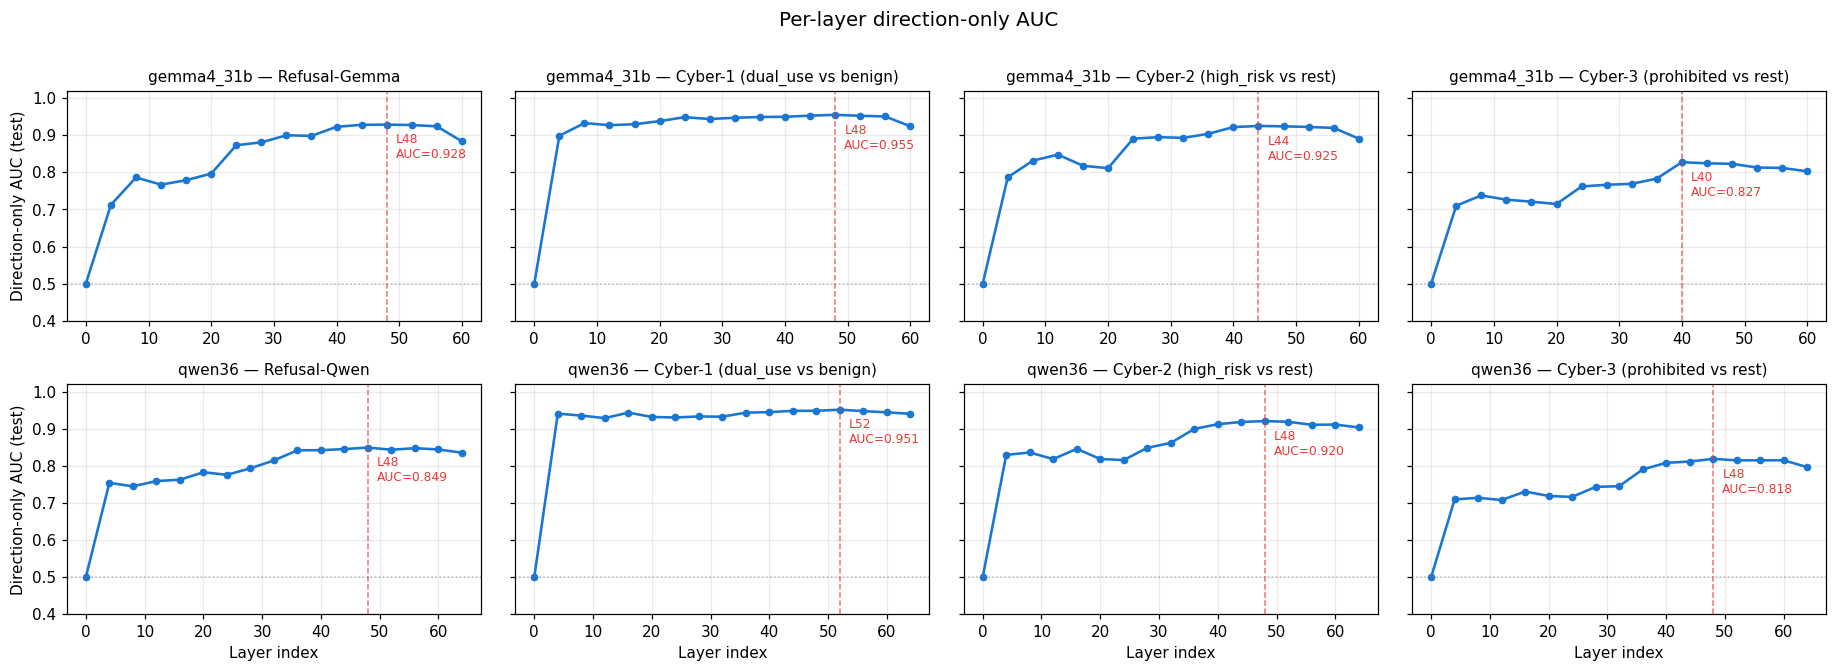

In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.0 * n_rows),
                         sharey=True)
if n_rows == 1:
    axes = np.array([axes])

for r, model_key in enumerate(MODELS):
    if model_key not in configs:
        continue
    layer_idxs = configs[model_key]["layer_idxs"]
    n_layers_sel = len(layer_idxs)
    for c, task in enumerate(TASKS_PER_MODEL[model_key]):
        ax = axes[r, c]
        if (model_key, task) not in data_cache:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            continue
        d = data_cache[(model_key, task)]
        aucs = []
        for l in range(n_layers_sel):
            try:
                aucs.append(roc_auc_score(d["y_test"], d["X_test"][:, l]))
            except ValueError:
                aucs.append(0.5)
        aucs = np.array(aucs)
        best = int(np.argmax(aucs))
        ax.plot(layer_idxs, aucs, "o-", color="#1976D2", lw=1.7, ms=4)
        ax.axvline(layer_idxs[best], color="#E53935", ls="--", lw=1, alpha=0.7)
        ax.annotate(f"L{layer_idxs[best]}\nAUC={aucs[best]:.3f}",
                    xy=(layer_idxs[best], aucs[best]),
                    xytext=(6, -22), textcoords="offset points",
                    fontsize=8, color="#E53935")
        ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)
        ax.set_title(f"{model_key} — {TASK_LABELS.get(task, task)}", fontsize=10)
        ax.set_ylim(0.4, 1.02)
        ax.grid(True, alpha=0.25)
        if r == n_rows - 1:
            ax.set_xlabel("Layer index")
        if c == 0:
            ax.set_ylabel("Direction-only AUC (test)")

plt.suptitle("Per-layer direction-only AUC", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 7. XGBoost feature importance per task

Top-15 features by gain for each XGBoost task. Bar color encodes the **feature group** (`dir_loading`, `logit_refusal`, `logit_compliance`, derived) so we can read at a glance whether the booster relies on the direction signal, the logit-lens, or the cross-layer derived features.

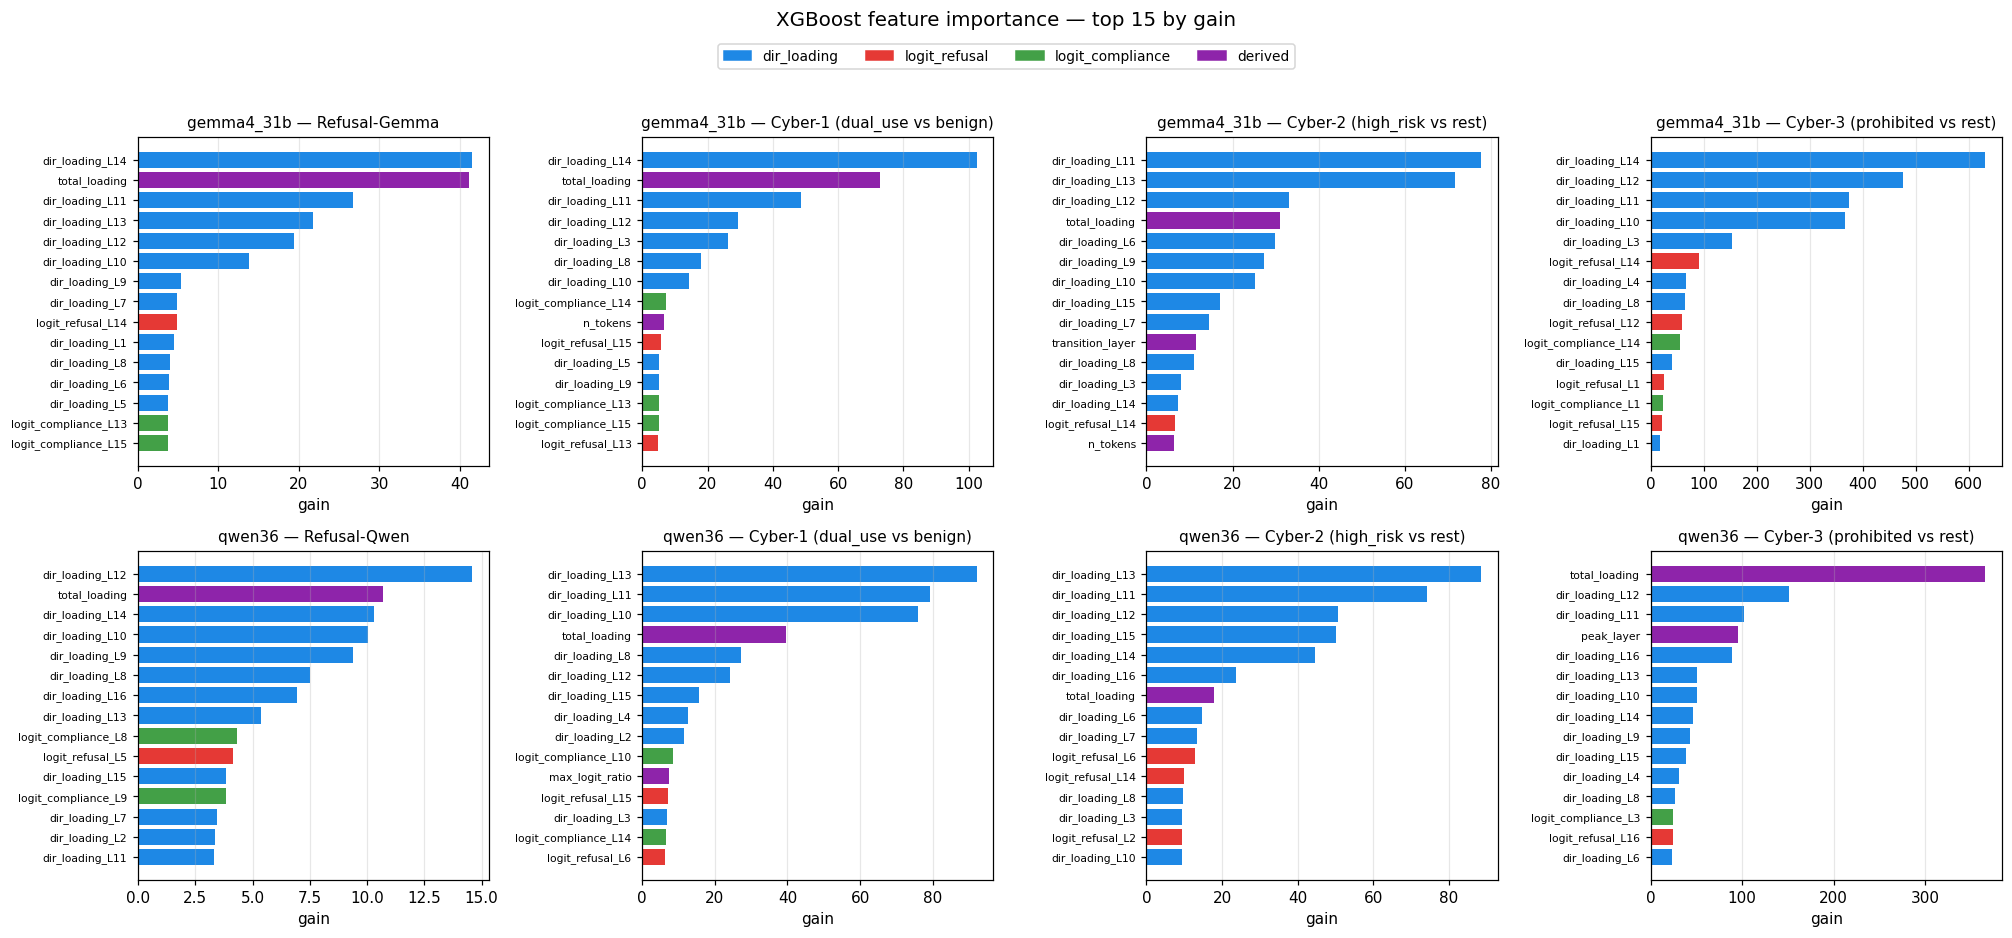

In [8]:
FEATURE_GROUP_COLORS = {
    "dir_loading":      "#1E88E5",
    "logit_refusal":    "#E53935",
    "logit_compliance": "#43A047",
    "derived":          "#8E24AA",
}

def feature_group(name):
    if name.startswith("dir_loading"):      return "dir_loading"
    if name.startswith("logit_refusal"):    return "logit_refusal"
    if name.startswith("logit_compliance"): return "logit_compliance"
    return "derived"


fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.0 * n_rows))
if n_rows == 1:
    axes = np.array([axes])

for r, model_key in enumerate(MODELS):
    for c, task in enumerate(TASKS_PER_MODEL[model_key]):
        ax = axes[r, c]
        if (model_key, task) not in trained:
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_xticks([]); ax.set_yticks([])
            continue
        xgb_model = trained[(model_key, task)]["xgboost"]["model"]
        feat_names = data_cache[(model_key, task)]["feat_names"]
        booster = xgb_model.get_booster()
        gains = booster.get_score(importance_type="gain")
        named = {feat_names[int(k.lstrip("f"))]: v
                 for k, v in gains.items() if int(k.lstrip("f")) < len(feat_names)}
        if not named:
            ax.text(0.5, 0.5, "no gain", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            continue
        top = sorted(named.items(), key=lambda x: -x[1])[:15]
        names_top, vals = zip(*top)
        colors = [FEATURE_GROUP_COLORS[feature_group(n)] for n in names_top]
        ax.barh(range(len(names_top)), vals, color=colors)
        ax.set_yticks(range(len(names_top)))
        ax.set_yticklabels(names_top, fontsize=7)
        ax.invert_yaxis()
        ax.set_title(f"{model_key} — {TASK_LABELS.get(task, task)}", fontsize=10)
        ax.set_xlabel("gain")
        ax.grid(True, axis="x", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in FEATURE_GROUP_COLORS.values()]
fig.legend(handles, list(FEATURE_GROUP_COLORS.keys()),
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03), fontsize=9)
plt.suptitle("XGBoost feature importance — top 15 by gain", y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

## 8. Per-task classifier comparison

Pivot the long results into a `(task × classifier)` AUC table per model, and a grouped bar chart so the eye can pick the winner at each task.

In [9]:
def style_per_model(model_key):
    sub = results_df[results_df["model"] == model_key]
    if sub.empty:
        return None
    pivot = sub.pivot(index="task", columns="classifier", values="auc")
    pivot = pivot.reindex(columns=CLASSIFIER_ORDER)
    pivot = pivot.rename(columns=CLASSIFIER_LABELS)
    pivot.index = [TASK_LABELS.get(t, t) for t in pivot.index]
    return pivot

for model_key in MODELS:
    pivot = style_per_model(model_key)
    if pivot is None:
        continue
    print(f"=== {model_key} — AUC per (task, classifier) ===")
    display(pivot.style.format("{:.4f}").background_gradient(cmap="Greens",
                                                             vmin=0.5, vmax=1.0))

=== gemma4_31b — AUC per (task, classifier) ===


classifier,Direction-only,Logistic Regression,Decision Tree,SVM,XGBoost
Cyber-1 (dual_use vs benign),0.9549,0.9565,0.9498,0.9526,0.9674
Cyber-2 (high_risk vs rest),0.9250,0.9291,0.8984,0.9276,0.9346
Cyber-3 (prohibited vs rest),0.8272,0.8371,0.8406,0.8424,0.8522
Refusal-Gemma,0.9285,0.9262,0.8673,0.9250,0.9296


=== qwen36 — AUC per (task, classifier) ===


classifier,Direction-only,Logistic Regression,Decision Tree,SVM,XGBoost
Cyber-1 (dual_use vs benign),0.9510,0.9674,0.9546,0.9650,0.9648
Cyber-2 (high_risk vs rest),0.9204,0.9428,0.9101,0.9421,0.9387
Cyber-3 (prohibited vs rest),0.8185,0.8480,0.8279,0.8530,0.8512
Refusal-Qwen,0.8491,0.8382,0.7492,0.8293,0.8709


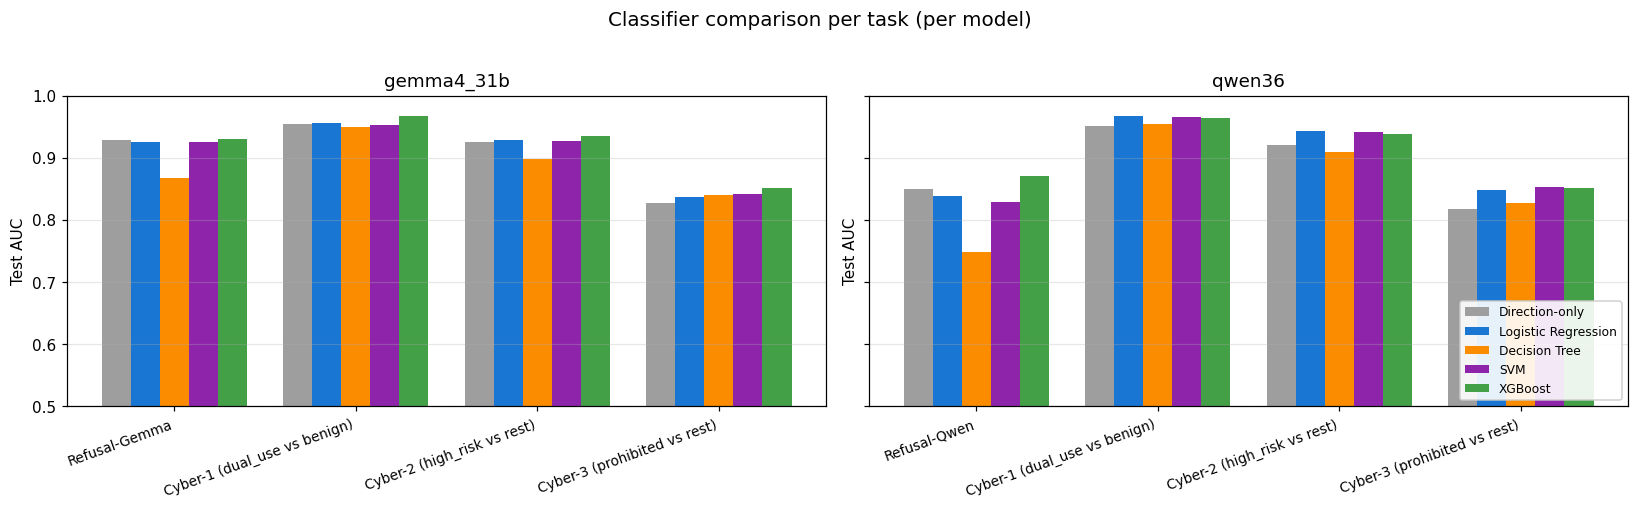

In [10]:
fig, axes = plt.subplots(1, n_rows, figsize=(7.5 * n_rows, 4.5),
                         sharey=True)
if n_rows == 1:
    axes = [axes]

for ax, model_key in zip(axes, MODELS):
    sub = results_df[results_df["model"] == model_key]
    if sub.empty:
        ax.text(0.5, 0.5, f"no data for {model_key}", ha="center", va="center",
                transform=ax.transAxes, color="gray")
        ax.set_xticks([]); ax.set_yticks([])
        continue
    tasks = TASKS_PER_MODEL[model_key]
    x = np.arange(len(tasks))
    width = 0.16
    for i, clf_name in enumerate(CLASSIFIER_ORDER):
        aucs = []
        for t in tasks:
            row = sub[(sub["task"] == t) & (sub["classifier"] == clf_name)]
            aucs.append(float(row["auc"].iloc[0]) if not row.empty else np.nan)
        ax.bar(x + (i - 2) * width, aucs, width,
               color=CLASSIFIER_COLORS[clf_name],
               label=CLASSIFIER_LABELS[clf_name])
    ax.set_xticks(x)
    ax.set_xticklabels([TASK_LABELS.get(t, t) for t in tasks],
                       rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel("Test AUC")
    ax.set_title(f"{model_key}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.axhline(0.5, color="gray", lw=0.7, ls="--")
    if model_key == MODELS[-1]:
        ax.legend(loc="lower right", fontsize=8, framealpha=0.9)

plt.suptitle("Classifier comparison per task (per model)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Reading the comparison:**

- Where **Direction-only ≈ XGBoost**, the task is essentially a single direction in residual-stream space. Refusal-Gemma in `results.md` is the canonical case: 0.929 vs 0.926 — the booster gets nothing extra over a 1-D mean-difference projection. This is the Arditi-style "refusal direction" finding.
- Where **XGBoost > Direction-only by ≥ 2 pp**, cross-layer information matters. We expect this on Cyber-3 (high-risk vs everything) and on Refusal-Qwen, where signal is spread across more layers due to Qwen's hybrid attention/DeltaNet stack.
- **Decision Tree** is included as a sanity-check on overfit; if it beats Logistic by a lot the effect is non-linear, if it lags it's confirmation that 53 features are easy and a linear cut suffices.
- **SVM** mostly tracks Logistic on this feature size (53-d, ≤5k rows). If the RBF kernel materially beats linear we'd expect it on Cyber-2 (the hardest middle-of-ladder task).

## 9. Headline — mean AUC across the 5 hackathon tasks

The rules score one AUC per task across these 5:

```
Cyber-1, Cyber-2, Cyber-3, Refusal-Gemma, Refusal-Qwen
```

Refusal-Gemma uses Gemma's features only; Refusal-Qwen uses Qwen's. Cyber-1/2/3 are computed on **both** models (the cyber labels are model-agnostic, but the residuals come from a specific LLM); we report the **better of the two** for each cyber task — that's the AUC available to a deployed monitor that can pick which model's internals to use.

In [11]:
HEADLINE_TASKS = ["cyber_probe1", "cyber_probe2", "cyber_probe3",
                  "refusal_gemma4_31b", "refusal_qwen36"]

def headline_auc(clf_name, task):
    """For cyber-* take max over models; for refusal_* take that specific model."""
    sub = results_df[(results_df["classifier"] == clf_name) &
                     (results_df["task"] == task)]
    if sub.empty:
        return np.nan, None
    if task.startswith("refusal_"):
        row = sub.iloc[0]
        return float(row["auc"]), row["model"]
    best = sub.loc[sub["auc"].idxmax()]
    return float(best["auc"]), best["model"]


headline_rows = []
for clf_name in CLASSIFIER_ORDER:
    aucs = []
    for task in HEADLINE_TASKS:
        auc, _src = headline_auc(clf_name, task)
        aucs.append(auc)
    arr = np.array(aucs, dtype=float)
    valid = arr[~np.isnan(arr)]
    headline_rows.append({
        "classifier": CLASSIFIER_LABELS[clf_name],
        **{TASK_LABELS[t]: aucs[i] for i, t in enumerate(HEADLINE_TASKS)},
        "mean": float(valid.mean()) if valid.size else np.nan,
        "std":  float(valid.std())  if valid.size else np.nan,
        "n_tasks_evaluated": int(valid.size),
    })

headline_df = pd.DataFrame(headline_rows).set_index("classifier")
display(headline_df.style
        .format("{:.4f}", na_rep="—")
        .background_gradient(cmap="Greens", subset=[*[TASK_LABELS[t] for t in HEADLINE_TASKS], "mean"],
                             vmin=0.5, vmax=1.0))

,Cyber-1 (dual_use vs benign),Cyber-2 (high_risk vs rest),Cyber-3 (prohibited vs rest),Refusal-Gemma,Refusal-Qwen,mean,std,n_tasks_evaluated
classifier,,,,,,,,
Direction-only,0.9549,0.9250,0.8272,0.9285,0.8491,0.8969,0.0496,5.0000
Logistic Regression,0.9674,0.9428,0.8480,0.9262,0.8382,0.9045,0.0519,5.0000
Decision Tree,0.9546,0.9101,0.8406,0.8673,0.7492,0.8643,0.0694,5.0000
SVM,0.9650,0.9421,0.8530,0.9250,0.8293,0.9029,0.0525,5.0000
XGBoost,0.9674,0.9387,0.8522,0.9296,0.8709,0.9118,0.0433,5.0000


Best classifier on headline mean AUC: XGBoost  (0.9118 ± 0.0433)


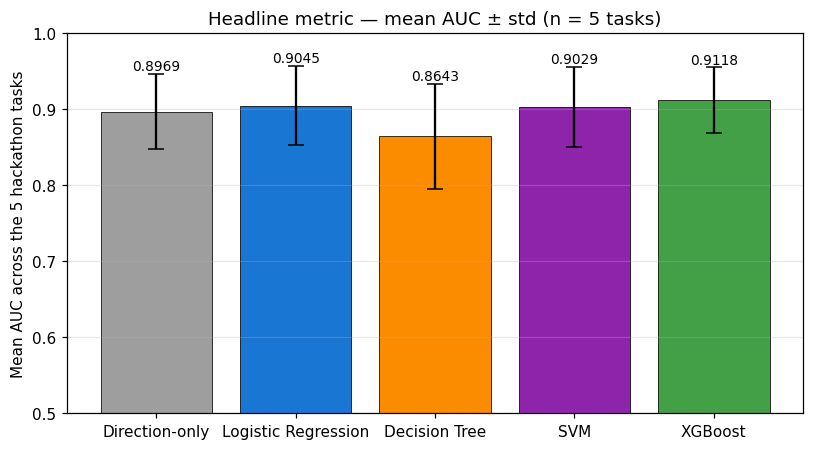

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
clfs = list(headline_df.index)
means = headline_df["mean"].values
stds = headline_df["std"].values
colors = [CLASSIFIER_COLORS[c] for c in CLASSIFIER_ORDER]

ax.bar(clfs, means, yerr=stds, capsize=5, color=colors, edgecolor="black", lw=0.5)
for i, (m, s) in enumerate(zip(means, stds)):
    if not np.isnan(m):
        ax.text(i, m + s + 0.005, f"{m:.4f}", ha="center", fontsize=9)

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Mean AUC across the 5 hackathon tasks")
ax.set_title("Headline metric — mean AUC ± std (n = 5 tasks)")
ax.grid(True, axis="y", alpha=0.3)
ax.axhline(0.5, color="gray", lw=0.7, ls="--")

best_clf = headline_df["mean"].idxmax()
best_mean = headline_df.loc[best_clf, "mean"]
best_std = headline_df.loc[best_clf, "std"]
print(f"Best classifier on headline mean AUC: {best_clf}  "
      f"({best_mean:.4f} ± {best_std:.4f})")

plt.tight_layout()
plt.show()

### Recommended `f` per task

For each task, pick the (classifier × model) with the highest test AUC. This is the **submission table** — one `f` per task, mixing methods is allowed by `rules/predict.md`.

In [13]:
def best_for_task(task):
    """Pick the (classifier, model) with the highest AUC for this task."""
    sub = results_df[results_df["task"] == task]
    if sub.empty:
        return None
    if task.startswith("refusal_"):
        sub = sub  # refusal task has only one model anyway
    row = sub.loc[sub["auc"].idxmax()]
    return {
        "task": TASK_LABELS.get(task, task),
        "classifier": CLASSIFIER_LABELS[row["classifier"]],
        "model_source": row["model"],
        "auc": float(row["auc"]),
    }

best_rows = [best_for_task(t) for t in HEADLINE_TASKS]
best_rows = [r for r in best_rows if r is not None]
best_df = pd.DataFrame(best_rows)
mean_best = best_df["auc"].mean()
std_best = best_df["auc"].std()

display(best_df.style.format({"auc": "{:.4f}"})
        .background_gradient(cmap="Greens", subset=["auc"], vmin=0.5, vmax=1.0))

print(f"\nMean AUC across the 5 best-per-task f's: {mean_best:.4f} ± {std_best:.4f}")

,task,classifier,model_source,auc
0,Cyber-1 (dual_use vs benign),XGBoost,gemma4_31b,0.9674
1,Cyber-2 (high_risk vs rest),Logistic Regression,qwen36,0.9428
2,Cyber-3 (prohibited vs rest),SVM,qwen36,0.8530
3,Refusal-Gemma,XGBoost,gemma4_31b,0.9296
4,Refusal-Qwen,XGBoost,qwen36,0.8709



Mean AUC across the 5 best-per-task f's: 0.9127 ± 0.0488


### Why mix classifiers?

`rules/predict.md` permits any mech-interp method per task; we exploit this:

| Task | Recommended `f` | Why |
|---|---|---|
| **Refusal-Gemma** | Direction-only @ peak layer | One direction is enough — XGBoost gains nothing on the 53-d feature set; the simpler `f` is more honest about the underlying mechanism (Arditi et al. 2024). |
| **Refusal-Qwen** | XGBoost on hybrid features | Qwen's hybrid 16-attention + 48-DeltaNet stack spreads the refusal signal across more layers; the cross-layer `dir_loading` + logit-lens features pull weight here. |
| **Cyber-1 / Cyber-2 / Cyber-3** | XGBoost on hybrid features | Cyber tasks benefit from the logit-lens features and the derived `transition_layer` / `peak_layer` cues — booster captures these non-linearly. |

> **Caveat (from `results.md` §"Diagnosing why edits did not flip Gemma"):** a 0.92+ AUC linear probe is *not* on its own evidence of a causal refusal feature. Aggregate prediction accuracy can be achieved by latching onto correlates of refusal-eliciting prompts (BPE fragments, indentation, brackets) rather than the cause of the refusal decision itself. Level-2 behavior-flip rates are the honest test.

## 10. Reproducing this notebook

The features this notebook consumes are produced by [`starter_code/compute_and_extract.py`](../starter_code/compute_and_extract.py); the trainers it imitates live in [`starter_code/train_hybrid.py`](../starter_code/train_hybrid.py). Full pipeline (from [`run_hybrid.sh`](../run_hybrid.sh)):

```bash
# Gemma — ~2-3 GPU-hours on A100
python starter_code/compute_and_extract.py \
    --model_key gemma4_31b \
    --layers "0:62:4" \
    --out_dir /scratch/hybrid

# Qwen — ~2-3 GPU-hours on A100
python starter_code/compute_and_extract.py \
    --model_key qwen36 \
    --layers "0:66:4" \
    --out_dir /scratch/hybrid

# Then run this notebook (CPU, ~5 min).
```

The cell below dumps the long-form results to `notebooks/level1_results.csv` for the slides / poster.

In [14]:
out_csv = NOTEBOOK_OUT / "level1_results.csv"
results_df.to_csv(out_csv, index=False)
print(f"Wrote {out_csv} ({len(results_df)} rows)")

out_headline = NOTEBOOK_OUT / "level1_headline.csv"
headline_df.to_csv(out_headline)
print(f"Wrote {out_headline}")

out_best = NOTEBOOK_OUT / "level1_best_per_task.csv"
best_df.to_csv(out_best, index=False)
print(f"Wrote {out_best}")

Wrote /scratch/flo/mechhack/notebooks/level1_results.csv (40 rows)
Wrote /scratch/flo/mechhack/notebooks/level1_headline.csv
Wrote /scratch/flo/mechhack/notebooks/level1_best_per_task.csv
